# Vector Space Model
**Information Retrieval course · Lab 06**

The **vector space model** (VSM) is the foundation of information retrieval where every object — a document, a query, a food, a song — becomes a point (a vector) in a feature space, and *relevance* becomes *geometry*. Objects whose vectors point in similar directions are similar.

In this lab we first build a **nutrition-based food recommender** (a compact numeric playground where we can see the geometry), and then apply exactly the same machinery to **text retrieval** with TF-IDF, BM25 and latent semantic analysis.

In [ ]:
!uv tree -d 1

Resolved 132 packages in 15ms
ir v0.1.0
├── beautifulsoup4 v4.15.0
├── bs4 v0.0.2
├── feedparser v6.0.14
├── ipykernel v7.3.0
├── matplotlib v3.10.9
├── nltk v3.10.3
├── pandas v2.3.3
├── requests v2.34.2
├── scikit-learn v1.7.2
├── selenium v4.48.0
└── statsmodels v0.15.0


## 1. Setup

In [ ]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.image import imread
from sklearn.decomposition import PCA

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
RNG = np.random.default_rng(42)

ModuleNotFoundError: No module named 'matplotlib'

## 2. Data and exploration
We use a table of nutrition facts: one row per food, one column per nutrient. The first row of the file holds **measurement units**, not data, so it is dropped. A missing value means "nutrient not present" and becomes `0`.

The loader tries the course repository first and falls back to a local copy of `nutrition.csv`, so the notebook also works offline.

In [ ]:
CSV_URL = "https://raw.githubusercontent.com/firas-jolha/ir/refs/heads/main/lab6/nutrition.csv"
LOCAL_CANDIDATES = ["nutrition.csv", "datasets/nutrition.csv", "../datasets/nutrition.csv", "../../datasets/nutrition.csv"]


def load_nutrition():
    """Load the nutrition table from the URL, falling back to a local file."""
    errors = []
    for source in [CSV_URL] + LOCAL_CANDIDATES:
        if not source.startswith("http") and not Path(source).exists():
            continue
        try:
            return pd.read_csv(source), source
        except Exception as exc:  # network error, bad file, ...
            errors.append(f"{source}: {exc}")
    raise FileNotFoundError(
        "Could not load nutrition.csv. Download it from\n"
        f"  {CSV_URL}\nand place it next to this notebook.\n" + "\n".join(errors)
    )


raw, source = load_nutrition()
print("Loaded from:", source)
raw.head(3)

Loaded from: https://raw.githubusercontent.com/IUCVLab/information-retrieval/main/datasets/nutrition.csv


,Food and Serving,Calories,Calories from Fat,Total Fat 1,Total Fat 2,Sodium 1,Sodium 2,Potassium 1,Potassium 2,Total Carbo-hydrate 1,...,Protein,Vitamin A,Vitamin C,Calcium,Iron,Saturated Fat,Saturated Fat 2,Chole-sterol 1,Chole-sterol 2,Food Type
0,NaN,NaN,NaN,(g),(%DV),(g),(%DV),(g),(%DV),(g),...,(g),(%DV),(%DV),(%DV),(%DV),(%DV),(mg),(%DV),(mg),NaN
1,"Asparagus, 5 spears (93 g/3.3 oz)",20.0,0.0,0,0,0,0,230,7,4,...,2,10,15,2,2,NaN,NaN,NaN,NaN,"Vegetables, Serving Size (gram weight/ ounce w..."
2,"Bell Pepper, 1 medium (148 g/5.3 oz)",25.0,0.0,0,0,40,2,220,6,6,...,1,4,190,2,4,NaN,NaN,NaN,NaN,"Vegetables, Serving Size (gram weight/ ounce w..."


In [15]:
units = raw.iloc[0]                       # first row holds the units of measurement
data = raw.iloc[1:].reset_index(drop=True)

feature_names = list(raw.columns[1:-1])   # numeric nutrient columns
names = [n.split(",")[0] for n in data["Food and Serving"]]   # short food names
classes = data["Food Type"].to_numpy()

# Feature matrix A: rows = foods, columns = nutrients
A = data[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)

print(f"{A.shape[0]} foods x {A.shape[1]} features, {len(set(classes))} food types")

61 foods x 22 features, 3 food types


Colours for food types — used consistently in all plots.

In [16]:
class_names = sorted(set(classes))
palette = cm.tab10(np.linspace(0, 1, 10))
class_color = {c: palette[i % 10] for i, c in enumerate(class_names)}
colors = [class_color[c] for c in classes]


def legend_handles():
    return [plt.Line2D([], [], marker="o", ls="", color=class_color[c], label=c) for c in class_names]

### 2.1 Look at the data first
Before modelling, check the scale of each feature and how many foods each type contains.

,unit,mean,std,min,max
Calories,NaN,72.541,43.690,10.0,200.0
Calories from Fat,NaN,9.344,17.523,0.0,90.0
Total Fat 1,(g),1.090,1.955,0.0,10.0
Total Fat 2,(%DV),1.705,2.940,0.0,15.0
Sodium 1,(g),53.361,82.324,0.0,330.0
Sodium 2,(%DV),2.230,3.490,0.0,14.0
Potassium 1,(g),284.672,120.585,70.0,620.0
Potassium 2,(%DV),8.164,3.489,2.0,18.0
Total Carbo-hydrate 1,(g),8.230,9.086,0.0,34.0
Total Carbo-hydrate 2,(%DV),2.787,3.050,0.0,11.0


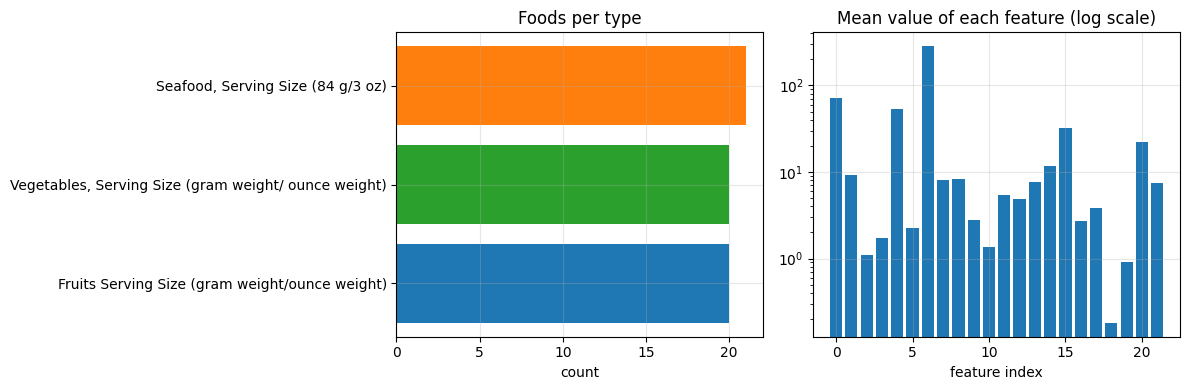

In [17]:
summary = pd.DataFrame(A, columns=feature_names).describe().T[["mean", "std", "min", "max"]]
summary.insert(0, "unit", [units[f] for f in feature_names])
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = pd.Series(classes).value_counts()
axes[0].barh(counts.index, counts.values, color=[class_color[c] for c in counts.index])
axes[0].set(title="Foods per type", xlabel="count"); axes[0].invert_yaxis()
axes[1].bar(range(A.shape[1]), A.mean(axis=0), color="tab:blue")
axes[1].set(yscale="log", title="Mean value of each feature (log scale)", xlabel="feature index")
plt.tight_layout(); plt.show()

**Observation.** The features live on wildly different scales (e.g. milligrams vs. grams). Because vector-space similarity is computed from raw coordinates, large-scale features will dominate.

## 3. Geometry of similarity
Let $a, b\in\mathbb{R}^n$. Three common ways to compare them:

| measure | formula | sensitive to length? |
|---|---|---|
| dot product | $a\cdot b$ | yes |
| Euclidean distance | $\lVert a-b\rVert_2$ | yes |
| **cosine similarity** | $\dfrac{a\cdot b}{\lVert a\rVert\,\lVert b\rVert}=\cos\theta$ | **no** |

Length matters for documents: a document repeated twice has the same *topic* but doubled term counts. Cosine says they are identical; Euclidean distance says they are far apart. A tiny 2D example makes this concrete.

,dot,euclidean,cosine
vector,,,
"same direction, 3x longer",15.0,4.472,1.000
"different direction, close",6.5,1.500,0.908
orthogonal,0.0,3.162,0.000


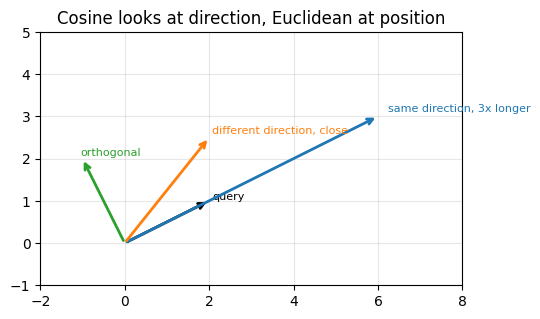

In [18]:
vecs = {"query": np.array([2.0, 1.0]),
        "same direction, 3x longer": np.array([6.0, 3.0]),
        "different direction, close": np.array([2.0, 2.5]),
        "orthogonal": np.array([-1.0, 2.0])}


def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


q2 = vecs["query"]
rows = [{"vector": n, "dot": q2 @ v, "euclidean": np.linalg.norm(q2 - v), "cosine": cosine(q2, v)}
        for n, v in vecs.items() if n != "query"]
display(pd.DataFrame(rows).set_index("vector"))

fig, ax = plt.subplots(figsize=(5.5, 5))
for (n, v), c in zip(vecs.items(), ["k", "tab:blue", "tab:orange", "tab:green"]):
    ax.annotate("", xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(*(v * 1.04), n, color=c, fontsize=8)
ax.set(xlim=(-2, 8), ylim=(-1, 5), aspect="equal", title="Cosine looks at direction, Euclidean at position")
plt.tight_layout(); plt.show()

**Takeaway.** The vector "same direction, 3x longer" is the *farthest* from the query in Euclidean distance but has cosine similarity exactly 1. In retrieval we want that behaviour: document length should not decide relevance.

|document |	text |	vector| Euclidean distance to query | cosine with query |
| -| -| -| - | - |
| d1 | "information retrieval" | (1, 1, 0) |0 | 1.00 |
| d2 | "information retrieval information retrieval information retrieval" (d1 pasted 3 times) | (3, 3, 0) | 	2.83 | 1.00 |
| d3 | "ranking ranking information" | (1, 0, 2) | 	2.24 | 0.32 |

## 4. Dimensionality reduction
With 22 features we cannot inspect the data directly. We project it to 3 dimensions in two ways and compare.

### 4.1 PCA
**Principal component analysis** *centres* the data and finds orthogonal directions of maximal variance. `explained_variance_ratio_` is the share of the total variance kept by each component.

In [19]:
pca = PCA(n_components=3)
A_pca = pca.fit_transform(A)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance: %.3f" % pca.explained_variance_ratio_.sum())

assert A_pca.shape == (A.shape[0], 3)
assert pca.explained_variance_ratio_.sum() > 0.9

Explained variance ratio: [0.568 0.245 0.097]
Total explained variance: 0.909


### 4.2 Truncated SVD
The **singular value decomposition** factors the matrix as $A = U\Sigma V^\top$. Keeping the $k$ largest singular values gives the best rank-$k$ approximation of $A$ (Eckart–Young theorem). The coordinates of the items in the reduced space are $U_k\Sigma_k = AV_k$.

Unlike PCA, SVD does **not centre** the data. It works on sparse, non-negative matrices and approximately preserves dot products, hence cosines.

In [20]:
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)

K = 3
A_svd = U[:, :K] * sigma[:K]      # same as U[:, :K] @ np.diag(sigma[:K])

energy = sigma**2 / np.sum(sigma**2)
print("Top singular values:", sigma[:5])
print("Energy kept by %d components: %.3f" % (K, energy[:K].sum()))

assert A_svd.shape == (A.shape[0], K)
assert np.allclose(A_svd, A @ Vt[:K].T)   # projection on the first K right singular vectors

Top singular values: [2554.666  664.062  422.175  270.788  217.706]
Energy kept by 3 components: 0.978


### 4.3 How many components do we need?
A *scree plot* shows how quickly variance (PCA) or squared singular values (SVD) decay. The cumulative curve tells us how much information a given number of components retains.

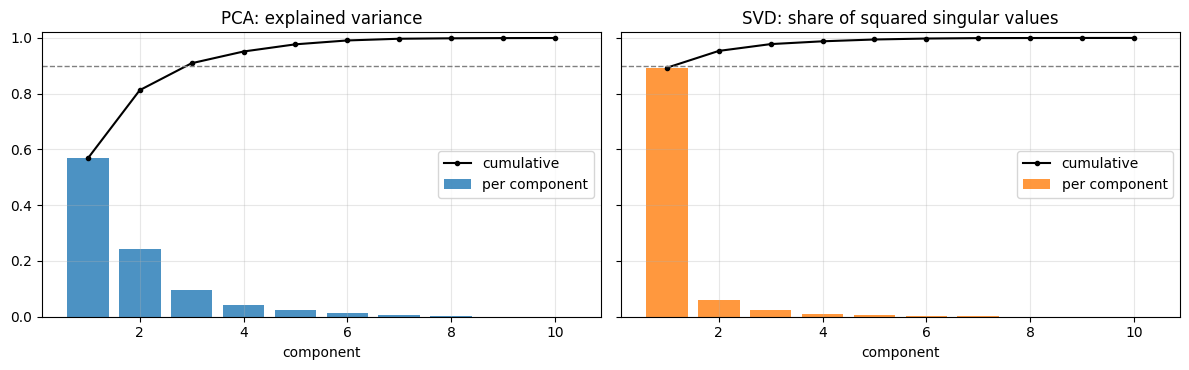

In [21]:
pca_full = PCA().fit(A)
n_show = min(10, A.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, vals, title, col in [(axes[0], pca_full.explained_variance_ratio_, "PCA: explained variance", "tab:blue"),
                             (axes[1], energy, "SVD: share of squared singular values", "tab:orange")]:
    ax.bar(range(1, n_show + 1), vals[:n_show], color=col, alpha=0.8, label="per component")
    ax.plot(range(1, n_show + 1), np.cumsum(vals)[:n_show], "k.-", label="cumulative")
    ax.axhline(0.9, ls="--", c="gray", lw=1)
    ax.set(title=title, xlabel="component", ylim=(0, 1.02)); ax.legend(loc="center right")
plt.tight_layout(); plt.show()

### 4.4 Visualisation
Each dot is a food coloured by type. Foods of the same type should form visible groups if nutrients carry type information.

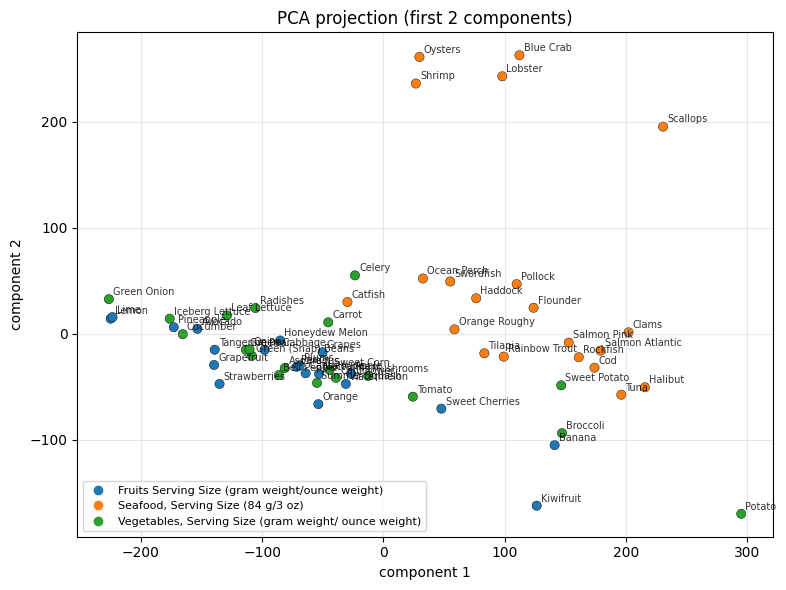

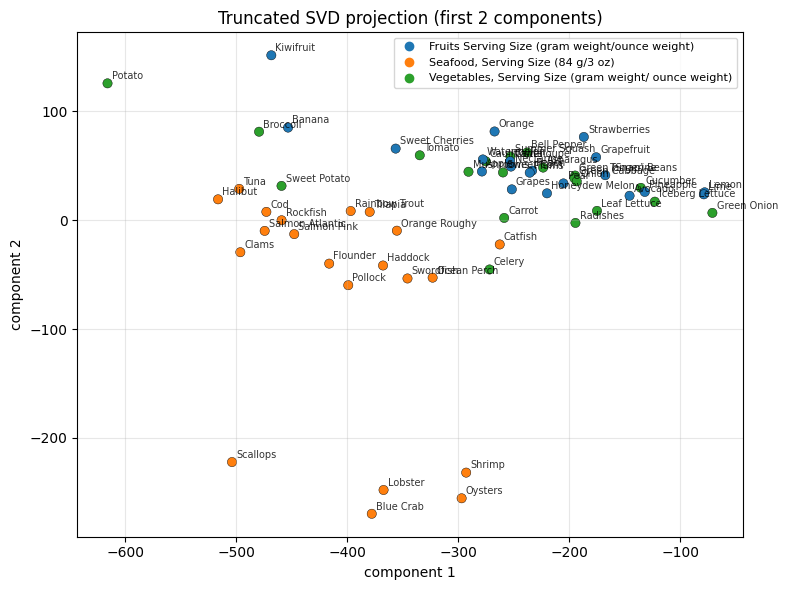

In [24]:
def scatter_2d(X, title, annotate=True, ax=None):
    show = ax is None
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=45, edgecolor="k", linewidth=0.3)
    if annotate:
        for (x, y), name in zip(X[:, :2], names):
            ax.annotate(name, (x, y), fontsize=7, alpha=0.8, xytext=(3, 3), textcoords="offset points")
    ax.set(title=title, xlabel="component 1", ylabel="component 2")
    ax.legend(handles=legend_handles(), fontsize=8, loc="best")
    if show:
        plt.tight_layout(); plt.show()


def scatter_3d(X, title):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection="3d")
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=colors, s=40, depthshade=True)
    ax.set(title=title, xlabel="c1", ylabel="c2", zlabel="c3")
    ax.legend(handles=legend_handles(), fontsize=7, loc="upper left")
    plt.tight_layout(); plt.show()


scatter_2d(A_pca, "PCA projection (first 2 components)")
scatter_2d(A_svd, "Truncated SVD projection (first 2 components)")

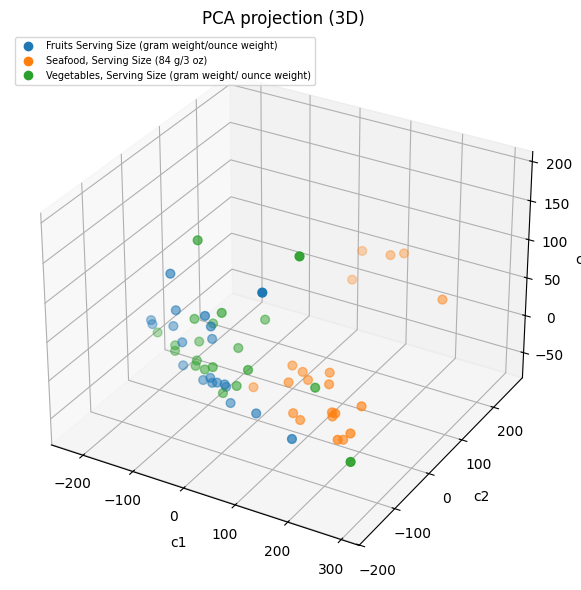

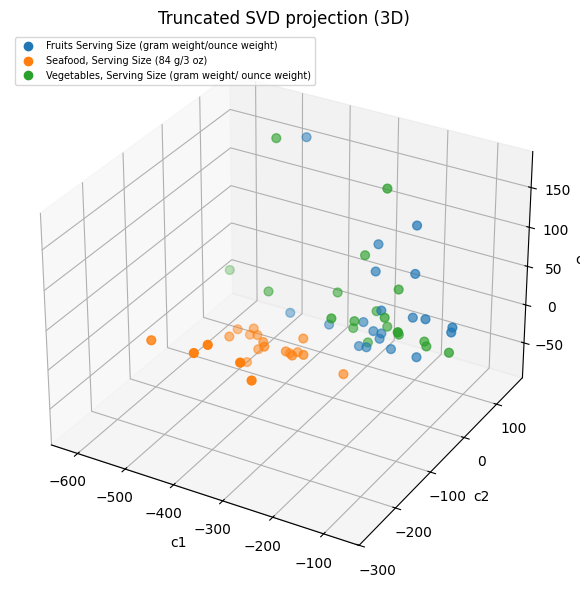

In [25]:
scatter_3d(A_pca, "PCA projection (3D)")
scatter_3d(A_svd, "Truncated SVD projection (3D)")

### 4.5 What do the components mean?
Each component is a weighted combination of the original features. The weights ("loadings") tell us which nutrients drive it.

PCA components:


,top features (loading)
component,
1,"Potassium 1 (+0.91), Sodium 1 (+0.28), Calorie..."
2,"Sodium 1 (+0.85), Potassium 1 (-0.34), Chole-s..."
3,"Vitamin C (+0.90), Sodium 1 (+0.34), Calories ..."


SVD right singular vectors:


,top features (loading)
component,
1,"Potassium 1 (-0.94), Calories (-0.24), Sodium ..."
2,"Sodium 1 (-0.87), Chole-sterol 1 (-0.30), Vita..."
3,"Vitamin C (+0.88), Sodium 1 (+0.36), Calories ..."


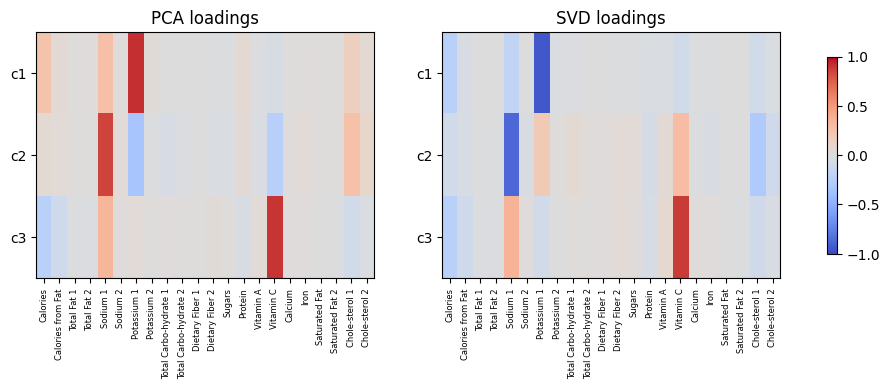

In [26]:
def top_loadings(components, n=4):
    rows = []
    for i, comp in enumerate(components, start=1):
        order = np.argsort(-np.abs(comp))[:n]
        rows.append({"component": i,
                     "top features (loading)": ", ".join(f"{feature_names[j]} ({comp[j]:+.2f})" for j in order)})
    return pd.DataFrame(rows).set_index("component")


print("PCA components:"); display(top_loadings(pca.components_))
print("SVD right singular vectors:"); display(top_loadings(Vt[:3]))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for ax, M, title in [(axes[0], pca.components_, "PCA loadings"), (axes[1], Vt[:3], "SVD loadings")]:
    im = ax.imshow(M, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
    ax.set(title=title, yticks=range(3), yticklabels=["c1", "c2", "c3"],
           xticks=range(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=90, fontsize=6); ax.grid(False)
plt.colorbar(im, ax=axes, shrink=0.8); plt.show()

### 4.6 A biplot
A biplot draws the foods *and* arrows for the most influential features in the same plane, so we can read which nutrients characterise which region.

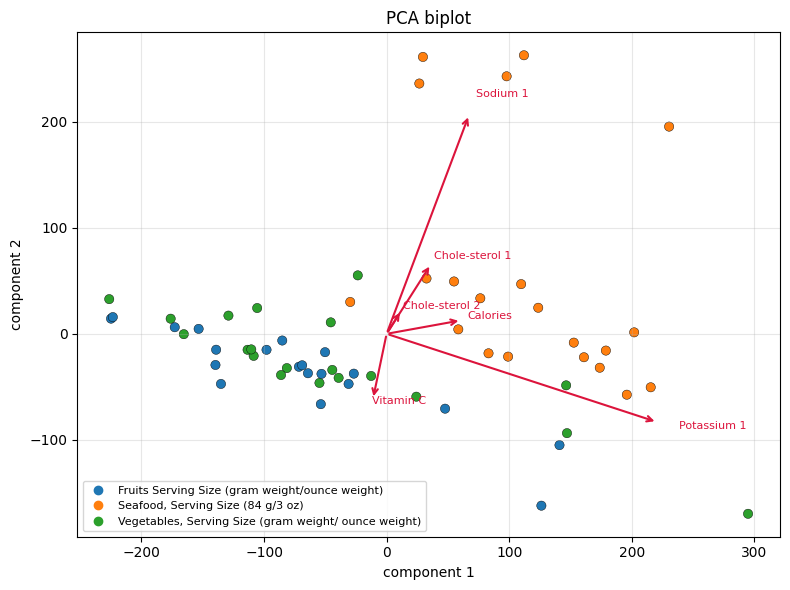

In [ ]:
def biplot(pca_model, X2, n_arrows=6):
    comps = pca_model.components_[:2]
    strength = np.linalg.norm(comps, axis=0)
    top = np.argsort(-strength)[:n_arrows]
    scale = 0.8 * np.abs(X2[:, :2]).max()
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter_2d(X2, "PCA biplot", annotate=False, ax=ax)
    for j in top:
        ax.annotate("", xy=comps[:, j] * scale / strength.max(), xytext=(0, 0),
                    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.5))
        ax.text(*(comps[:, j] * scale / strength.max() * 1.08), feature_names[j], color="crimson", fontsize=8)
    plt.tight_layout(); plt.show()


biplot(pca, A_pca)

**Question 1.** The two 2D plots differ. Why? (Hint: PCA subtracts the mean before the decomposition.) What do you expect the first SVD component to capture, given that all features are non-negative?

## 5. Normalisation and cosine similarity
$$\cos(a, b) = \frac{a \cdot b}{\lVert a\rVert\,\lVert b\rVert}.$$

If every vector is first scaled to unit length, $\hat a = a/\lVert a\rVert$, the cosine is simply the dot product $\hat a\cdot\hat b$. Normalising once up front reduces ranking *all* items against a query to **one matrix–vector product**.

For unit vectors, Euclidean distance and cosine are even equivalent in ranking: $\lVert\hat a-\hat b\rVert^2 = 2 - 2\cos(a,b)$.

In [29]:
def norm_vectors(M, eps=1e-12):
    """Scale every row of M to unit L2 norm. All-zero rows stay zero."""
    M = np.asarray(M, dtype=float)
    norms = np.linalg.norm(M, axis=1, keepdims=True)
    return M / np.maximum(norms, eps)


def find_k_closest(query, collection, k=6):
    """Indices and cosine similarities of the k rows of `collection` closest to `query`.

    `collection` must be row-normalised (see norm_vectors); `query` is normalised here.
    Results are sorted by decreasing similarity.
    """
    q = np.asarray(query, dtype=float)
    q = q / max(np.linalg.norm(q), 1e-12)
    sims = collection @ q
    k = min(k, len(sims))
    top = np.argpartition(-sims, k - 1)[:k]      # O(n) selection of the k best ...
    top = top[np.argsort(-sims[top])]            # ... then sort only those k
    return top, sims[top]


# --- sanity checks ---------------------------------------------------------
test = norm_vectors(np.array([[3.0, 4.0], [0.0, 0.0], [1.0, 0.0]]))
assert np.allclose(np.linalg.norm(test[[0, 2]], axis=1), 1.0)
assert np.allclose(test[1], 0.0)
idx, s = find_k_closest(np.array([1.0, 0.1]), norm_vectors(np.array([[1, 0], [0, 1], [1, 1.0]])), k=2)
assert list(idx) == [0, 2] and s[0] > s[1]

# unit vectors: ||a-b||^2 = 2 - 2 cos(a,b)
a, b = norm_vectors(RNG.random((2, 5)))
assert np.isclose(np.linalg.norm(a - b) ** 2, 2 - 2 * (a @ b))

### 5.1 Similarity matrix
A heatmap of all pairwise cosine similarities in the full space. Rows are sorted by food type, so groups of similar foods appear as blocks on the diagonal.

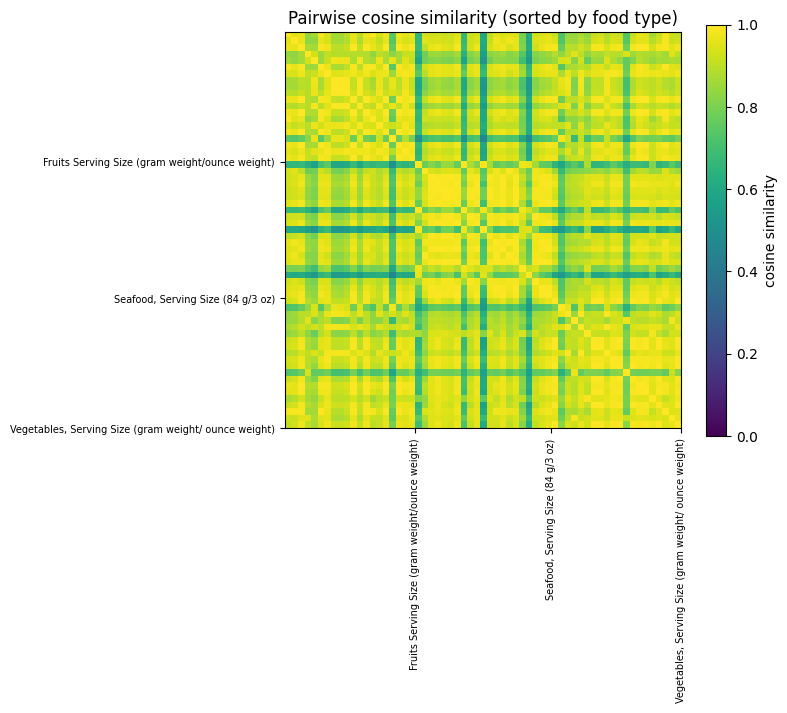

In [30]:
A_n = norm_vectors(A)
order = np.argsort(classes, kind="stable")
S = A_n[order] @ A_n[order].T

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S, cmap="viridis", vmin=0, vmax=1)
bounds = np.cumsum([np.sum(classes == c) for c in class_names])
ax.set(title="Pairwise cosine similarity (sorted by food type)", xticks=bounds - 0.5, yticks=bounds - 0.5,
       xticklabels=class_names, yticklabels=class_names)
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7); plt.setp(ax.get_yticklabels(), fontsize=7)
ax.grid(False)
plt.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout(); plt.show()

### 5.2 Distribution of similarities
Are nearest neighbours *really* special? Compare the similarity of **same-type** pairs and **different-type** pairs.

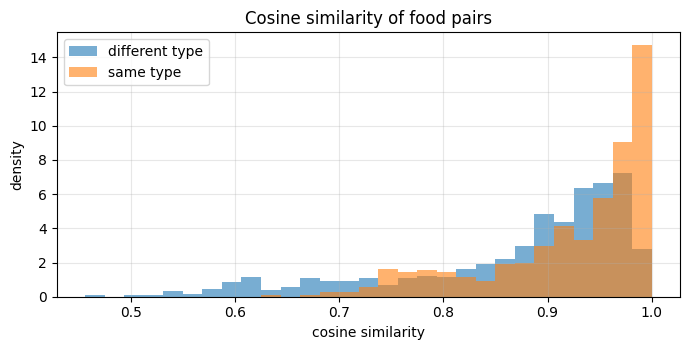

mean cosine, same type: 0.923 | different type: 0.870


In [31]:
iu = np.triu_indices(len(names), k=1)
same = (classes[:, None] == classes[None, :])[iu]
sims_all = (A_n @ A_n.T)[iu]

fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.linspace(sims_all.min(), 1, 30)
ax.hist(sims_all[~same], bins=bins, alpha=0.6, label="different type", density=True)
ax.hist(sims_all[same], bins=bins, alpha=0.6, label="same type", density=True)
ax.set(title="Cosine similarity of food pairs", xlabel="cosine similarity", ylabel="density"); ax.legend()
plt.tight_layout(); plt.show()
print("mean cosine, same type: %.3f | different type: %.3f" % (sims_all[same].mean(), sims_all[~same].mean()))

## 6. The recommender
Given a food the user likes, return foods with the most similar nutrient profile. We compare three representations:

| representation | dimensions |
|---|---|
| full | 22 |
| PCA | 3 |
| SVD | 3 |

In [32]:
def recommend(food_index, matrix, k=5):
    """Top-k most similar foods to `food_index` (the food itself is excluded)."""
    M = norm_vectors(matrix)
    idx, sims = find_k_closest(M[food_index], M, k=k + 1)
    keep = [(i, s) for i, s in zip(idx, sims) if i != food_index][:k]
    return pd.DataFrame({"food": [names[i] for i, _ in keep],
                         "type": [classes[i] for i, _ in keep],
                         "cosine": [round(float(s), 4) for _, s in keep]})


def food_id(name):
    matches = [i for i, n in enumerate(names) if n.lower() == name.lower()]
    if not matches:
        raise KeyError(f"'{name}' not found; try one of {names[:5]} ...")
    return matches[0]


query_name = "Ocean Perch"
q = food_id(query_name) if query_name in names else 48 % len(names)
print("Recommendations for:", names[q], f"({classes[q]})")
results = {"full (22-D)": recommend(q, A), "PCA (3-D)": recommend(q, A_pca), "SVD (3-D)": recommend(q, A_svd)}
for label, df in results.items():
    print("\n" + label); display(df)

Recommendations for: Ocean Perch (Seafood, Serving Size (84 g/3 oz))

full (22-D)


,food,type,cosine
0,Swordfish,"Seafood, Serving Size (84 g/3 oz)",0.996
1,Haddock,"Seafood, Serving Size (84 g/3 oz)",0.993
2,Flounder,"Seafood, Serving Size (84 g/3 oz)",0.992
3,Pollock,"Seafood, Serving Size (84 g/3 oz)",0.990
4,Salmon Pink,"Seafood, Serving Size (84 g/3 oz)",0.986



PCA (3-D)


,food,type,cosine
0,Swordfish,"Seafood, Serving Size (84 g/3 oz)",0.966
1,Haddock,"Seafood, Serving Size (84 g/3 oz)",0.845
2,Blue Crab,"Seafood, Serving Size (84 g/3 oz)",0.821
3,Scallops,"Seafood, Serving Size (84 g/3 oz)",0.815
4,Shrimp,"Seafood, Serving Size (84 g/3 oz)",0.808



SVD (3-D)


,food,type,cosine
0,Swordfish,"Seafood, Serving Size (84 g/3 oz)",1.000
1,Pollock,"Seafood, Serving Size (84 g/3 oz)",1.000
2,Haddock,"Seafood, Serving Size (84 g/3 oz)",0.999
3,Flounder,"Seafood, Serving Size (84 g/3 oz)",0.998
4,Clams,"Seafood, Serving Size (84 g/3 oz)",0.995


### 6.1 How similar are the lists?
**Overlap@k** = share of the full-space top-k that a reduced representation also returns. Averaging over *all* foods is more reliable than looking at one query.

In [33]:
def neighbours(matrix, k=5):
    """Top-k neighbour indices (excluding self) for every row, by cosine similarity."""
    M = norm_vectors(matrix)
    S = M @ M.T
    np.fill_diagonal(S, -np.inf)
    return np.argsort(-S, axis=1)[:, :k]


def overlap_at_k(nn_a, nn_b):
    return float(np.mean([len(set(a) & set(b)) / len(a) for a, b in zip(nn_a, nn_b)]))


nn_full = neighbours(A)
for label, M in [("PCA (3-D)", A_pca), ("SVD (3-D)", A_svd)]:
    print(f"{label}: mean overlap@5 with full space = {overlap_at_k(nn_full, neighbours(M)):.3f}")

PCA (3-D): mean overlap@5 with full space = 0.384
SVD (3-D): mean overlap@5 with full space = 0.590


**Question 2.** Which reduced representation preserves the full-space neighbours better? Why can PCA change cosine similarities more than SVD? (Hint: PCA moves the origin to the mean, and angles are measured at the origin.)

### 6.2 Pictures (optional)
If a folder `nutr_img/` with `<food name>.jpg` files is available we show the query and its recommendations. Otherwise the foods are displayed as text cards.

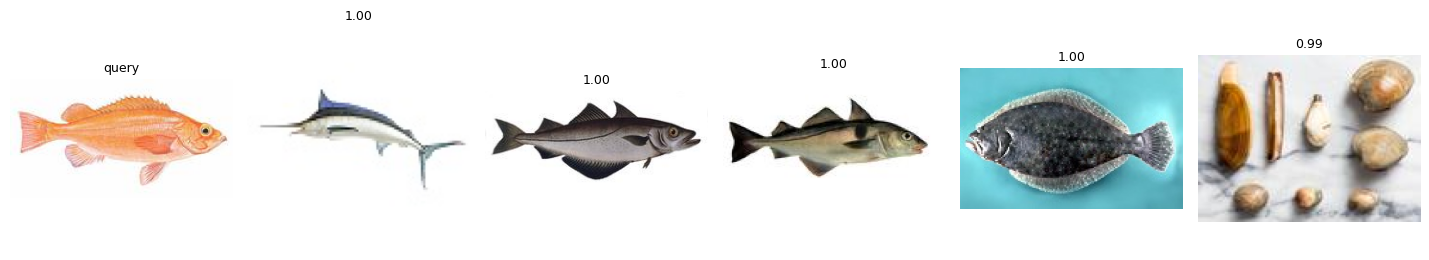

In [35]:
IMG_DIRS = [Path(p) for p in ("nutr_img", "datasets/nutr_img", "../datasets/nutr_img", "../../datasets/nutr_img")]
img_dir = next((d for d in IMG_DIRS if d.is_dir()), None)


def show_recommendations(food_index, matrix, k=5):
    rec = recommend(food_index, matrix, k)
    items = [(names[food_index], "query")] + [(r.food, f"{r.cosine:.2f}") for r in rec.itertuples()]
    fig, axes = plt.subplots(1, len(items), figsize=(2.4 * len(items), 2.8))
    for ax, (name, note) in zip(np.atleast_1d(axes), items):
        path = img_dir / f"{name.lower()}.jpg" if img_dir else None
        if path is not None and path.exists():
            ax.imshow(imread(path))
        else:
            ax.text(0.5, 0.5, name, ha="center", va="center", wrap=True)
        ax.set_title(note, fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()


if img_dir is None:
    print("No image folder found - showing text cards.")
show_recommendations(q, A_svd)

## 7. Feature scaling and weighting
Cosine similarity is only as good as the vector representation. Since features have very different scales, large-scale nutrients dominate the angle. Common remedies, all of which have analogues in text retrieval:

| transform | idea | text analogue |
|---|---|---|
| none | raw amounts | raw term counts |
| `log1p` | dampen large values | sub-linear tf: $1+\log tf$ |
| z-score | every feature has mean 0, std 1 | — |
| max-scaling | divide each feature by its maximum (keeps zeros, non-negative) | — |
| idf-style weights | down-weight features that are large for *every* food | **idf** |

We compare them by **precision@k**: the share of each food's top-k neighbours that have the same *food type*. This is a proxy for relevance (we treat "same type" as "relevant").

,precision@5
raw,0.807
log1p,0.836
max-scaled,0.866
max-scaled + idf-style,0.869
z-score,0.816


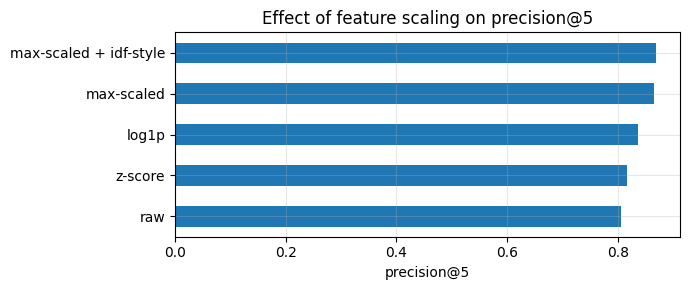

In [36]:
def precision_at_k(matrix, k=5):
    """Mean share of the top-k neighbours (cosine) having the same food type as the query."""
    nn = neighbours(matrix, k)
    return float((classes[nn] == classes[:, None]).mean())


def zscore(M):
    sd = M.std(axis=0); sd[sd == 0] = 1
    return (M - M.mean(axis=0)) / sd


def maxscale(M):
    mx = M.max(axis=0); mx[mx == 0] = 1
    return M / mx


def idf_weight(M):
    # features that are "present" (above the median) for many foods carry less information
    df = (M > np.median(M, axis=0)).sum(axis=0) + 1
    return M * np.log(len(M) / df + 1)


representations = {
    "raw": A,
    "log1p": np.log1p(A),
    "max-scaled": maxscale(A),
    "max-scaled + idf-style": idf_weight(maxscale(A)),
    "z-score": zscore(A),
}
scores = pd.Series({n: precision_at_k(M) for n, M in representations.items()}, name="precision@5")
display(scores.to_frame())

ax = scores.sort_values().plot.barh(figsize=(7, 3), color="tab:blue")
ax.set(title="Effect of feature scaling on precision@5", xlabel="precision@5"); plt.tight_layout(); plt.show()

**Question 3.** Which transform works best here, and why might z-scoring be *dangerous* in a sparse text setting? (Hint: what happens to zeros when you subtract the mean?)

Do the recommendations for our query change?

In [37]:
for label in ["raw", "max-scaled", "z-score"]:
    print(f"\n{label}:"); display(recommend(q, representations[label]))


raw:


,food,type,cosine
0,Swordfish,"Seafood, Serving Size (84 g/3 oz)",0.996
1,Haddock,"Seafood, Serving Size (84 g/3 oz)",0.993
2,Flounder,"Seafood, Serving Size (84 g/3 oz)",0.992
3,Pollock,"Seafood, Serving Size (84 g/3 oz)",0.990
4,Salmon Pink,"Seafood, Serving Size (84 g/3 oz)",0.986



max-scaled:


,food,type,cosine
0,Orange Roughy,"Seafood, Serving Size (84 g/3 oz)",0.896
1,Clams,"Seafood, Serving Size (84 g/3 oz)",0.871
2,Blue Crab,"Seafood, Serving Size (84 g/3 oz)",0.854
3,Rainbow Trout,"Seafood, Serving Size (84 g/3 oz)",0.849
4,Salmon Pink,"Seafood, Serving Size (84 g/3 oz)",0.842



z-score:


,food,type,cosine
0,Blue Crab,"Seafood, Serving Size (84 g/3 oz)",0.714
1,Rainbow Trout,"Seafood, Serving Size (84 g/3 oz)",0.701
2,Orange Roughy,"Seafood, Serving Size (84 g/3 oz)",0.622
3,Salmon Pink,"Seafood, Serving Size (84 g/3 oz)",0.581
4,Clams,"Seafood, Serving Size (84 g/3 oz)",0.562


## 8. Evaluation
Retrieval systems are judged by *relevance*. With our "same type = relevant" proxy we can measure quality quantitatively.

* **Precision@k** — share of the top-k results that are relevant.
* **Per-class precision** — which food types are easy or hard?
* **Dimensionality sweep** — how does quality change with the number of components?
* **Cosine vs. Euclidean** — does the choice of similarity matter?

In [38]:
# Per-class precision@5 in the full space
nn5 = neighbours(A, 5)
per_class = pd.Series({c: (classes[nn5[classes == c]] == c).mean() for c in class_names}, name="precision@5")
display(per_class.sort_values(ascending=False).to_frame())

,precision@5
"Seafood, Serving Size (84 g/3 oz)",0.971
Fruits Serving Size (gram weight/ounce weight),0.780
"Vegetables, Serving Size (gram weight/ ounce weight)",0.660


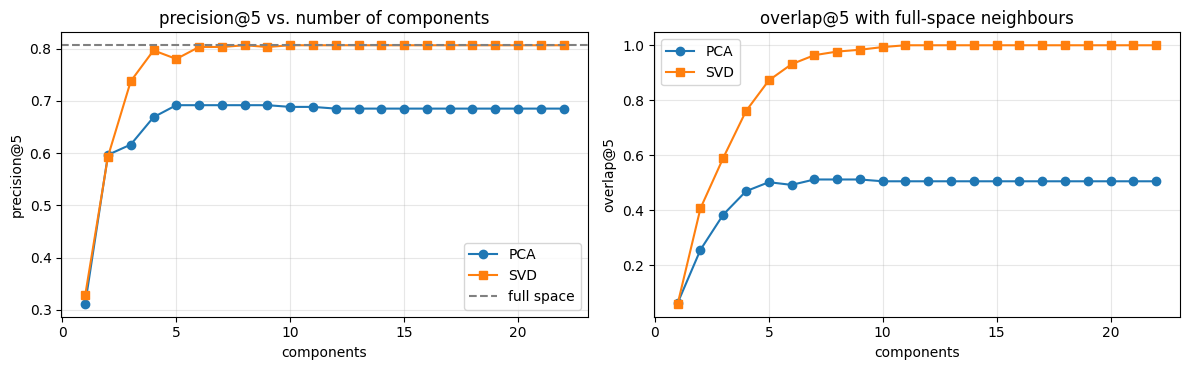

Smallest number of SVD components giving overlap@5 >= 0.9: 6


In [39]:
# Sweep: precision@5 and overlap@5 as a function of the number of components
max_k = A.shape[1]
Z_pca = PCA().fit_transform(A)
Z_svd = U * sigma

ks = list(range(1, max_k + 1))
prec_pca = [precision_at_k(Z_pca[:, :k]) for k in ks]
prec_svd = [precision_at_k(Z_svd[:, :k]) for k in ks]
ov_pca = [overlap_at_k(nn_full, neighbours(Z_pca[:, :k])) for k in ks]
ov_svd = [overlap_at_k(nn_full, neighbours(Z_svd[:, :k])) for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(ks, prec_pca, "o-", label="PCA"); axes[0].plot(ks, prec_svd, "s-", label="SVD")
axes[0].axhline(precision_at_k(A), ls="--", c="gray", label="full space")
axes[0].set(title="precision@5 vs. number of components", xlabel="components", ylabel="precision@5"); axes[0].legend()
axes[1].plot(ks, ov_pca, "o-", label="PCA"); axes[1].plot(ks, ov_svd, "s-", label="SVD")
axes[1].set(title="overlap@5 with full-space neighbours", xlabel="components", ylabel="overlap@5"); axes[1].legend()
plt.tight_layout(); plt.show()

smallest = next((k for k, o in zip(ks, ov_svd) if o >= 0.9), None)
print("Smallest number of SVD components giving overlap@5 >= 0.9:", smallest)

In [40]:
# Cosine vs. Euclidean retrieval (raw features)
def neighbours_euclidean(M, k=5):
    D = np.linalg.norm(M[:, None, :] - M[None, :, :], axis=-1)
    np.fill_diagonal(D, np.inf)
    return np.argsort(D, axis=1)[:, :k]


nn_euc = neighbours_euclidean(A)
prec_euc = float((classes[nn_euc] == classes[:, None]).mean())
print(f"precision@5 - cosine: {precision_at_k(A):.3f} | Euclidean: {prec_euc:.3f}")
print(f"overlap@5 between cosine and Euclidean neighbours: {overlap_at_k(nn_full, nn_euc):.3f}")

precision@5 - cosine: 0.807 | Euclidean: 0.682
overlap@5 between cosine and Euclidean neighbours: 0.456


**Question 4.** Why do cosine and Euclidean rankings disagree on this data? What kind of foods are "far" in Euclidean distance but "close" in cosine? Is the "same type" proxy a fair measure of relevance — can you think of foods of different types that a nutritionist would call similar?

## 9. Query by profile and relevance feedback
So far the query was an existing food. In IR the query is usually *a vector we construct*.

### 9.1 Query by profile
Describe the nutrient profile you want (e.g. "high protein, almost no carbohydrates") and retrieve matching foods. We look up features by substring so the code does not depend on the exact column spelling.

In [41]:
def find_feature(substring):
    hits = [i for i, f in enumerate(feature_names) if substring.lower() in f.lower()]
    return hits[0] if hits else None


def profile_query(**wanted):
    """Build a query vector; keys are substrings of feature names, values the desired amount."""
    q_vec = np.zeros(A.shape[1])
    for key, value in wanted.items():
        j = find_feature(key)
        if j is None:
            raise KeyError(f"No feature containing '{key}'. Available: {feature_names}")
        q_vec[j] = value
    return q_vec


try:
    profile = profile_query(protein=1.0)        # "protein only": no carbs, no fat, ...
    idx, sims = find_k_closest(profile, norm_vectors(A), k=8)
    display(pd.DataFrame({"food": [names[i] for i in idx], "type": classes[idx], "cosine": sims.round(3)}))
except KeyError as err:
    print(err)

,food,type,cosine
0,Ocean Perch,"Seafood, Serving Size (84 g/3 oz)",0.064
1,Catfish,"Seafood, Serving Size (84 g/3 oz)",0.061
2,Tilapia,"Seafood, Serving Size (84 g/3 oz)",0.057
3,Haddock,"Seafood, Serving Size (84 g/3 oz)",0.056
4,Shrimp,"Seafood, Serving Size (84 g/3 oz)",0.054
5,Tuna,"Seafood, Serving Size (84 g/3 oz)",0.052
6,Rainbow Trout,"Seafood, Serving Size (84 g/3 oz)",0.049
7,Pollock,"Seafood, Serving Size (84 g/3 oz)",0.049


### 9.2 Relevance feedback with the Rocchio algorithm
After seeing the first results the user marks some as *relevant* and others as *not relevant*. Rocchio moves the query vector towards the relevant items and away from the non-relevant ones:

$$\vec q_{new} = \alpha\,\vec q + \frac{\beta}{|R|}\sum_{d\in R}\vec d - \frac{\gamma}{|N|}\sum_{d\in N}\vec d,$$

typical values $\alpha=1,\ \beta=0.75,\ \gamma=0.15$ (all vectors unit length). Let us pretend the user likes the first two recommendations for our query food and dislikes the last.

In [42]:
def rocchio(q_vec, relevant, nonrelevant, alpha=1.0, beta=0.75, gamma=0.15):
    new = alpha * q_vec
    if len(relevant):
        new = new + beta * np.mean(relevant, axis=0)
    if len(nonrelevant):
        new = new - gamma * np.mean(nonrelevant, axis=0)
    return np.maximum(new, 0)       # keep weights non-negative, as in the classic formulation


M = norm_vectors(A)
first = recommend(q, A, k=5)
rel_ids = [names.index(n) for n in first["food"][:2]]
non_ids = [names.index(n) for n in first["food"][-1:]]

new_q = rocchio(M[q], M[rel_ids], M[non_ids])
idx, sims = find_k_closest(new_q, M, k=6)
print(f"Original query: {names[q]}; liked: {[names[i] for i in rel_ids]}; disliked: {[names[i] for i in non_ids]}")
display(pd.DataFrame({"food": [names[i] for i in idx if i != q][:5], "type": [classes[i] for i in idx if i != q][:5]}))

Original query: Ocean Perch; liked: ['Swordfish', 'Haddock']; disliked: ['Salmon Pink']


,food,type
0,Swordfish,"Seafood, Serving Size (84 g/3 oz)"
1,Haddock,"Seafood, Serving Size (84 g/3 oz)"
2,Flounder,"Seafood, Serving Size (84 g/3 oz)"
3,Pollock,"Seafood, Serving Size (84 g/3 oz)"
4,Salmon Pink,"Seafood, Serving Size (84 g/3 oz)"


## 10. From foods to text: TF-IDF, BM25 and LSA
Everything we did carries over to **documents**: rows become documents, columns become *terms*, and entries are *term weights*. The matrix is usually huge and sparse, but the geometry is the same.

We use a tiny corpus so that every number can be inspected. (With so little text, LSA is only *illustrative* — it needs real collections to shine.)

In [43]:
docs = {
    "d1": "information retrieval is the process of finding relevant documents for a query",
    "d2": "the vector space model represents documents and queries as vectors of term weights",
    "d3": "cosine similarity measures the angle between a query vector and a document vector",
    "d4": "tf idf weighting gives high weight to terms frequent in a document but rare in the collection",
    "d5": "singular value decomposition reveals latent semantic structure in term document matrices",
    "d6": "pizza recipes need fresh tomatoes mozzarella and basil",
    "d7": "the chef cooked pasta with tomatoes and garlic for dinner",
    "d8": "search engines rank documents by relevance to the user query",
}
STOP = {"the", "of", "is", "for", "a", "and", "as", "to", "in", "by", "but", "with", "between", "an"}


def tokenize(text):
    return [t for t in re.findall(r"[a-z]+", text.lower()) if t not in STOP]


doc_ids = list(docs)
tokens = {d: tokenize(t) for d, t in docs.items()}
vocab = sorted({t for ts in tokens.values() for t in ts})
t_index = {t: i for i, t in enumerate(vocab)}
print(f"{len(doc_ids)} documents, {len(vocab)} distinct terms")

# term-frequency matrix: documents x terms
TF = np.zeros((len(doc_ids), len(vocab)))
for i, d in enumerate(doc_ids):
    for t, c in Counter(tokens[d]).items():
        TF[i, t_index[t]] = c

8 documents, 55 distinct terms


### 10.1 TF-IDF
* **tf** — how often a term occurs in a document (we use the sub-linear $1+\log tf$ for $tf>0$).
* **idf** — $\log\frac{N}{df_t}$, where $df_t$ is the number of documents containing $t$. Rare terms are more discriminative.
* weight $w_{t,d} = (1+\log tf_{t,d})\cdot idf_t$, then each document vector is L2-normalised.

In [44]:
N = len(doc_ids)
df_t = (TF > 0).sum(axis=0)
idf = np.log(N / df_t)

logtf = np.where(TF > 0, 1 + np.log(np.where(TF > 0, TF, 1)), 0)
TFIDF = norm_vectors(logtf * idf)

top_terms = pd.DataFrame({"term": vocab, "df": df_t, "idf": idf.round(2)}).sort_values("idf", ascending=False)
print("Rarest terms (highest idf) vs. most common terms:")
display(pd.concat([top_terms.head(4), top_terms.tail(4)]).set_index("term"))


def vectorize_query(text, weighting="tfidf"):
    v = np.zeros(len(vocab))
    for t, c in Counter(tokenize(text)).items():
        if t in t_index:
            v[t_index[t]] = (1 + np.log(c)) * (idf[t_index[t]] if weighting == "tfidf" else 1.0)
    return v


def search(query_text, matrix, k=4, weighting="tfidf"):
    qv = vectorize_query(query_text, weighting)
    if not qv.any():
        return pd.DataFrame(columns=["doc", "score", "text"])
    idx, sims = find_k_closest(qv, norm_vectors(matrix), k=k)
    return pd.DataFrame({"doc": [doc_ids[i] for i in idx], "score": sims.round(3),
                         "text": [docs[doc_ids[i]][:60] + "..." for i in idx]})


query_text = "vector model for ranking documents"
print("Query:", query_text)
res = search(query_text, TFIDF)
display(res)
assert res.iloc[0]["doc"] == "d2"

Rarest terms (highest idf) vs. most common terms:


,df,idf
term,,
angle,1,2.08
basil,1,2.08
chef,1,2.08
collection,1,2.08
tomatoes,2,1.39
document,3,0.98
documents,3,0.98
query,3,0.98


Query: vector model for ranking documents


,doc,score,text
0,d2,0.484,the vector space model represents documents an...
1,d3,0.244,cosine similarity measures the angle between a...
2,d1,0.074,information retrieval is the process of findin...
3,d8,0.074,search engines rank documents by relevance to ...


**TF-IDF vs. raw counts.** Raw counts let frequent but uninformative words ("documents") dominate. Compare the two rankings for a query that mixes a rare and a common word:

In [45]:
q2_text = "documents about tomatoes"
print("raw counts:"); display(search(q2_text, TF, weighting="raw"))
print("tf-idf:");     display(search(q2_text, TFIDF))

raw counts:


,doc,score,text
0,d7,0.289,the chef cooked pasta with tomatoes and garlic...
1,d1,0.267,information retrieval is the process of findin...
2,d6,0.267,pizza recipes need fresh tomatoes mozzarella a...
3,d8,0.267,search engines rank documents by relevance to ...


tf-idf:


,doc,score,text
0,d7,0.233,the chef cooked pasta with tomatoes and garlic...
1,d6,0.214,pizza recipes need fresh tomatoes mozzarella a...
2,d1,0.117,information retrieval is the process of findin...
3,d8,0.117,search engines rank documents by relevance to ...


### 10.2 BM25
BM25 is the dominant ranking function of the last 30 years. It refines TF-IDF with **term-frequency saturation** (the 10th occurrence of a word adds little) and **document-length normalisation**:

$$\text{BM25}(q,d)=\sum_{t\in q} idf_t\cdot\frac{tf_{t,d}\,(k_1+1)}{tf_{t,d}+k_1\left(1-b+b\,\frac{|d|}{\text{avgdl}}\right)},\qquad k_1\approx1.2,\ b\approx0.75.$$

Note that BM25 is *not* a cosine in a vector space — it is a sum of per-term scores — but it is still a function of the same term-document matrix.

BM25:


,doc,score,text
0,d2,3.848,the vector space model represents documents an...
1,d3,1.769,cosine similarity measures the angle between a...
2,d1,1.001,information retrieval is the process of findin...
3,d8,1.001,search engines rank documents by relevance to ...


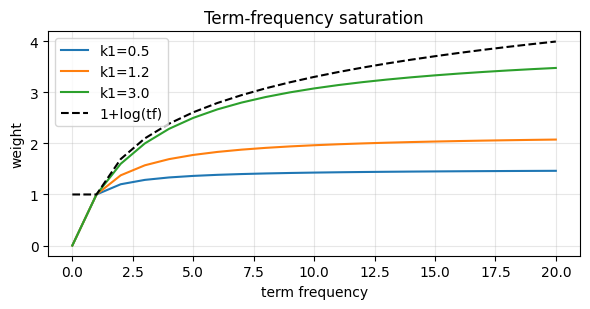

In [46]:
def bm25_scores(query_text, k1=1.2, b=0.75):
    doc_len = TF.sum(axis=1)
    avgdl = doc_len.mean()
    idf_bm25 = np.log((N - df_t + 0.5) / (df_t + 0.5) + 1)       # the non-negative "+1" variant
    scores = np.zeros(N)
    for t in set(tokenize(query_text)):
        if t not in t_index:
            continue
        j = t_index[t]
        tf = TF[:, j]
        scores += idf_bm25[j] * tf * (k1 + 1) / (tf + k1 * (1 - b + b * doc_len / avgdl))
    return scores


def bm25_search(query_text, k=4, **kw):
    s = bm25_scores(query_text, **kw)
    order = np.argsort(-s)[:k]
    return pd.DataFrame({"doc": [doc_ids[i] for i in order], "score": s[order].round(3),
                         "text": [docs[doc_ids[i]][:60] + "..." for i in order]})


print("BM25:"); display(bm25_search(query_text))

# Saturation: score contribution of a term as tf grows
tfs = np.arange(0, 21)
plt.figure(figsize=(6, 3.2))
for k1 in (0.5, 1.2, 3.0):
    plt.plot(tfs, tfs * (k1 + 1) / (tfs + k1), label=f"k1={k1}")
plt.plot(tfs, 1 + np.log(np.maximum(tfs, 1)) * (tfs > 0), "k--", label="1+log(tf)")
plt.xlabel("term frequency"); plt.ylabel("weight"); plt.title("Term-frequency saturation"); plt.legend()
plt.tight_layout(); plt.show()

### 10.3 Latent semantic analysis (LSA)
Exactly as with the foods, we apply truncated SVD to the term-document matrix. Each document becomes a short dense vector in a **latent topic space**. Documents that use *related* words end up close even if they share no term.

A new query is mapped into the same space by **folding in**: $q_k = q\,V_k$ (the same projection used for the documents, since $U_k\Sigma_k = XV_k$).

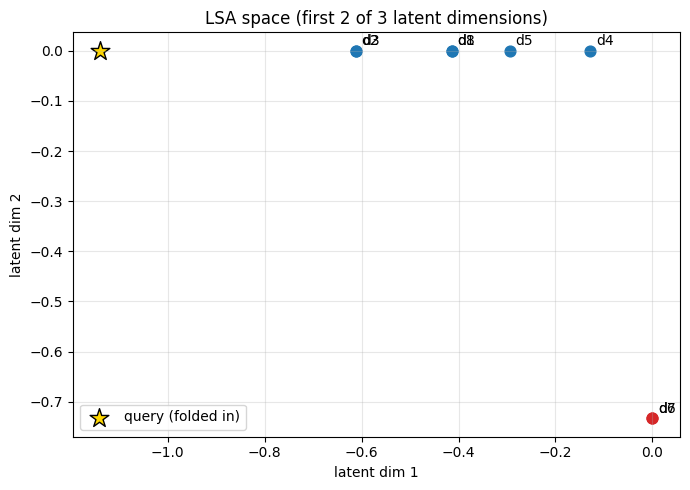

LSA ranking for: vector model for ranking documents


,doc,cosine
0,d3,0.992
1,d2,0.982
2,d5,0.640
3,d4,0.513


In [47]:
Ud, sd, Vtd = np.linalg.svd(TFIDF, full_matrices=False)
k_lsa = 3
docs_lsa = Ud[:, :k_lsa] * sd[:k_lsa]          # = TFIDF @ Vtd[:k].T

fig, ax = plt.subplots(figsize=(7, 5))
topic = ["cooking" if d in ("d6", "d7") else "IR" for d in doc_ids]
for i, d in enumerate(doc_ids):
    ax.scatter(*docs_lsa[i, :2], c="tab:red" if topic[i] == "cooking" else "tab:blue", s=60)
    ax.annotate(d, docs_lsa[i, :2], xytext=(4, 4), textcoords="offset points")
qv = vectorize_query(query_text) @ Vtd[:k_lsa].T
ax.scatter(*qv[:2], marker="*", s=200, c="gold", edgecolor="k", label="query (folded in)")
ax.set(title="LSA space (first 2 of 3 latent dimensions)", xlabel="latent dim 1", ylabel="latent dim 2"); ax.legend()
plt.tight_layout(); plt.show()

idx, sims = find_k_closest(qv, norm_vectors(docs_lsa), k=4)
print("LSA ranking for:", query_text)
display(pd.DataFrame({"doc": [doc_ids[i] for i in idx], "cosine": sims.round(3)}))

In [48]:
# LSA can return documents that share NO term with the query
def lsa_search(query_text, k=4):
    qk = vectorize_query(query_text) @ Vtd[:k_lsa].T
    idx, sims = find_k_closest(qk, norm_vectors(docs_lsa), k=k)
    return pd.DataFrame({"doc": [doc_ids[i] for i in idx], "cosine": sims.round(3)})


for q_text in ["tf idf weights", "latent semantic"]:
    print(f"Query: {q_text!r}")
    print("TF-IDF (exact term match only):"); display(search(q_text, TFIDF, k=4)[["doc", "score"]])
    print("LSA:"); display(lsa_search(q_text))

print("A query whose words are all unknown gives an empty vector:", not vectorize_query("ranking").any(),
      "- the vocabulary mismatch problem (d8 contains 'rank', not 'ranking'); stemming mitigates it.")

Query: 'tf idf weights'
TF-IDF (exact term match only):


,doc,score
0,d4,0.361
1,d2,0.217
2,d1,0.000
3,d3,0.000


LSA:


,doc,cosine
0,d5,0.975
1,d4,0.929
2,d2,0.895
3,d3,0.864


Query: 'latent semantic'
TF-IDF (exact term match only):


,doc,score
0,d5,0.48
1,d1,0.00
2,d3,0.00
3,d2,0.00


LSA:


,doc,cosine
0,d5,0.999
1,d4,0.995
2,d2,0.740
3,d3,0.695


A query whose words are all unknown gives an empty vector: True - the vocabulary mismatch problem (d8 contains 'rank', not 'ranking'); stemming mitigates it.


**Question 5.** In the LSA plot, which documents form clusters? Why is `d5` (about SVD) placed near the other IR documents although it shares few words with them? What are the trade-offs of LSA compared to plain TF-IDF (hint: speed, interpretability, exact term matching)?